# 20260730_data Baslangic Analizi

Bu notebook, `data/20260730_data.xlsx` veri seti icin modelleme oncesi hazirlik ve kesifsel analiz adimlarini icerir.

In [1]:
# 1) Notebook Kurulumu ve Kutuphane Ice Aktarimi
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Kutuphaneler yuklendi.')

Kutuphaneler yuklendi.


In [2]:
# 2) Veri Setini Yukleme ve Dosya Dogrulama
DATA_PATH = '../data/20260730_data.xlsx'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'Dosya bulunamadi: {DATA_PATH}')

df = pd.read_excel(DATA_PATH)

print(f'Dosya yukuendi: {DATA_PATH}')
print(f'Satir x Sutun: {df.shape[0]:,} x {df.shape[1]}')

Dosya yukuendi: ../data/20260730_data.xlsx
Satir x Sutun: 336,139 x 12


In [3]:
# 3) Ilk Veri Kontrolleri (shape, head, info)
print('Shape:', df.shape)
print('\nKolonlar:')
print(df.columns.tolist())

print('\nIlk 5 satir:')
display(df.head())

print('\nSon 5 satir:')
display(df.tail())

print('\nInfo:')
df.info(show_counts=True)

Shape: (336139, 12)

Kolonlar:
['konaklama_yil', 'konaklama_ay', 'konaklama_gun', 'sehir_id', 'sehir_adi', 'hotel_id', 'hotel_region_name', 'konaklayan_kisi_sayisi', 'oda_sayisi', 'voucher_created_date', 'voucher_checkin_date', 'voucher_checkout_date']

Ilk 5 satir:


,konaklama_yil,konaklama_ay,konaklama_gun,sehir_id,sehir_adi,hotel_id,hotel_region_name,konaklayan_kisi_sayisi,oda_sayisi,voucher_created_date,voucher_checkin_date,voucher_checkout_date
0,2024,1,26,29,Antalya,1171,Üç Kum Tepesi,4,1,2024-01-20 16:37:07,2024-01-25 00:00:00.000,2024-01-28 00:00:00.000
1,2025,11,15,22,Adana,2789,Seyhan,12,4,2025-11-10 07:34:13,2025-11-15 00:00:00.000,2025-11-16 00:00:00.000
2,2025,7,25,29,Antalya,1094,NaN,2,1,2025-06-30 13:36:26,2025-07-23 00:00:00.000,2025-07-28 00:00:00.000
3,2025,1,20,5085,Girne,1967,NaN,3,1,2024-12-21 08:09:14,2025-01-20 00:00:00.000,2025-01-24 00:00:00.000
4,2023,4,17,62,İzmir,1551,Özdere,3,1,2023-04-13 10:50:46,2023-04-17 00:00:00.000,2023-04-20 00:00:00.000



Son 5 satir:


,konaklama_yil,konaklama_ay,konaklama_gun,sehir_id,sehir_adi,hotel_id,hotel_region_name,konaklayan_kisi_sayisi,oda_sayisi,voucher_created_date,voucher_checkin_date,voucher_checkout_date
336134,2025,10,11,5085,Girne,821,NaN,4,2,2025-10-09 13:57:21,2025-10-10 00:00:00.000,2025-10-12 00:00:00.000
336135,2026,5,25,43,Çanakkale,275577,Bozcaada,2,1,2026-05-21 07:51:27.023,2026-05-24 00:00:00.000,2026-05-26 00:00:00.000
336136,2021,8,20,80,Muğla,428,Günlüklü,23,7,2021-01-26 08:42:51,2021-08-09 00:00:00.000,2021-08-21 00:00:00.000
336137,2023,9,5,100,Yalova,481,NaN,2,1,2023-09-01 18:29:54,2023-09-03 00:00:00.000,2023-09-07 00:00:00.000
336138,2026,9,19,80,Muğla,201669,NaN,2,1,2026-02-27 06:57:10,2026-09-13 00:00:00.000,2026-09-20 00:00:00.000



Info:
<class 'pandas.DataFrame'>
RangeIndex: 336139 entries, 0 to 336138
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   konaklama_yil           336139 non-null  int64 
 1   konaklama_ay            336139 non-null  int64 
 2   konaklama_gun           336139 non-null  int64 
 3   sehir_id                336139 non-null  int64 
 4   sehir_adi               336139 non-null  str   
 5   hotel_id                336139 non-null  int64 
 6   hotel_region_name       263973 non-null  str   
 7   konaklayan_kisi_sayisi  336139 non-null  int64 
 8   oda_sayisi              336139 non-null  int64 
 9   voucher_created_date    336139 non-null  object
 10  voucher_checkin_date    336139 non-null  str   
 11  voucher_checkout_date   336139 non-null  str   
dtypes: int64(7), object(1), str(4)
memory usage: 30.8+ MB


In [4]:
# 4) Sutun Tipleri ve Temel Donusumler
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
object_cols = df.select_dtypes(include=['object']).columns.tolist()

# Tarih gibi gorunen object kolonlari datetime'a cevir
datetime_cols = []
for col in object_cols:
    parsed = pd.to_datetime(df[col], errors='coerce')
    if parsed.notna().mean() > 0.8:
        df[col] = parsed
        datetime_cols.append(col)

# Donusumlerden sonra kolon listelerini guncelle
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
date_cols = df.select_dtypes(include=['datetime64[ns]', 'datetime64[ns, UTC]']).columns.tolist()

print('Sayisal kolon sayisi:', len(numeric_cols))
print('Kategorik kolon sayisi:', len(cat_cols))
print('Tarih kolon sayisi:', len(date_cols))
if datetime_cols:
    print('Datetime donusturulen kolonlar:', datetime_cols)

Sayisal kolon sayisi: 7
Kategorik kolon sayisi: 2
Tarih kolon sayisi: 3
Datetime donusturulen kolonlar: ['voucher_created_date', 'voucher_checkin_date', 'voucher_checkout_date']


/var/folders/vj/jyn2qp8j5jj6ptl_dmkdj89w0000gp/T/ipykernel_48104/1867612022.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include=['object']).columns.tolist()
/var/folders/vj/jyn2qp8j5jj6ptl_dmkdj89w0000gp/T/ipykernel_48104/1867612022.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col], errors='coerce')
/var/folders/vj/jyn2qp8j5jj6ptl_dmkdj89w0000gp/T/ipykernel_48104/

In [5]:
# 5) Eksik Deger Analizi ve Isleme
missing_count = df.isna().sum()
missing_ratio = (missing_count / len(df) * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({'missing_count': missing_count, 'missing_ratio_pct': missing_ratio})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_ratio_pct', ascending=False)

print('Eksik deger iceren kolon sayisi:', len(missing_df))
display(missing_df.head(30))

# Basit doldurma stratejisi
for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna('Unknown')
for col in date_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode(dropna=True).iloc[0] if not df[col].mode(dropna=True).empty else pd.Timestamp('1970-01-01'))

print('Eksik degerler dolduruldu. Kalan eksik toplam:', int(df.isna().sum().sum()))

Eksik deger iceren kolon sayisi: 1


,missing_count,missing_ratio_pct
hotel_region_name,72166,21.469095


Eksik degerler dolduruldu. Kalan eksik toplam: 0


In [6]:
# 6) Tekrarli Kayit ve Tutarsizlik Kontrolleri
before_rows = len(df)
dup_count = int(df.duplicated().sum())
print('Duplicate satir sayisi:', dup_count)
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
print('Duplicate temizligi sonrasi satir sayisi:', len(df), '(once:', before_rows, ')')

# Kategorik kolonlarda metin normalize et
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

print('Kategorik metinlerde strip islemi uygulandi.')

Duplicate satir sayisi: 0
Duplicate temizligi sonrasi satir sayisi: 336139 (once: 336139 )
Kategorik metinlerde strip islemi uygulandi.


In [7]:
# 7) Aykiri Deger Tespiti (IQR clip)
def iqr_clip(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return series.clip(lower=low, upper=high)

for col in numeric_cols:
    if df[col].nunique() > 10:
        df[col] = iqr_clip(df[col])

print('IQR tabanli clipping sayisal kolonlara uygulandi.')

IQR tabanli clipping sayisal kolonlara uygulandi.


,count,mean,std,min,25%,50%,75%,max
konaklama_yil,336139.0,2023.662720,1.620376,2021.0,2022.0,2024.0,2025.0,2026.0
konaklama_ay,336139.0,7.045957,2.200654,3.0,6.0,7.0,8.0,11.0
konaklama_gun,336139.0,16.089198,8.849828,1.0,8.0,16.0,24.0,31.0
sehir_id,336139.0,56.967388,35.001356,22.0,29.0,43.0,80.0,156.5
hotel_id,336139.0,53927.561223,84784.118916,370.0,744.0,1962.0,167847.0,418501.5
konaklayan_kisi_sayisi,336139.0,5.902517,5.186441,1.0,2.0,4.0,8.0,17.0
oda_sayisi,336139.0,2.282603,1.787451,1.0,1.0,1.0,3.0,6.0


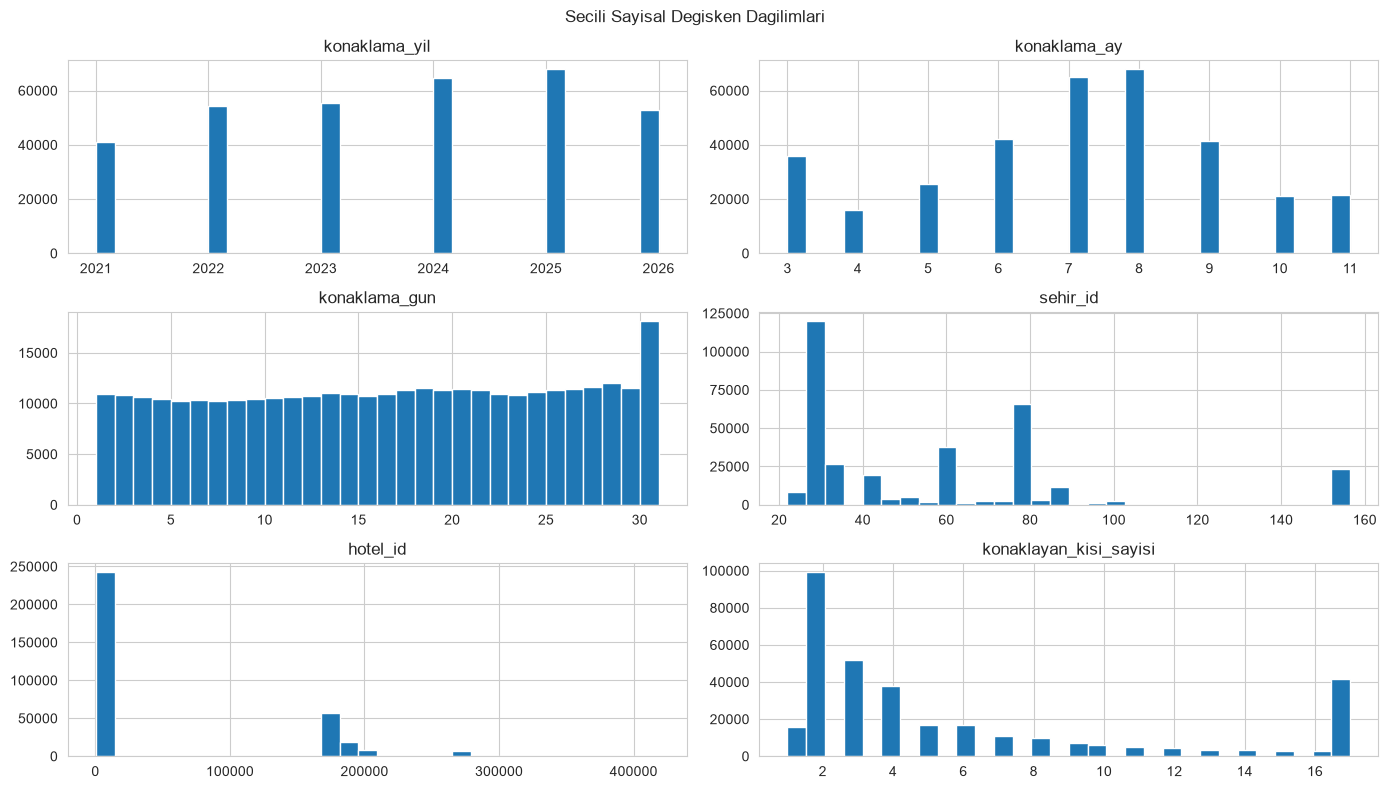

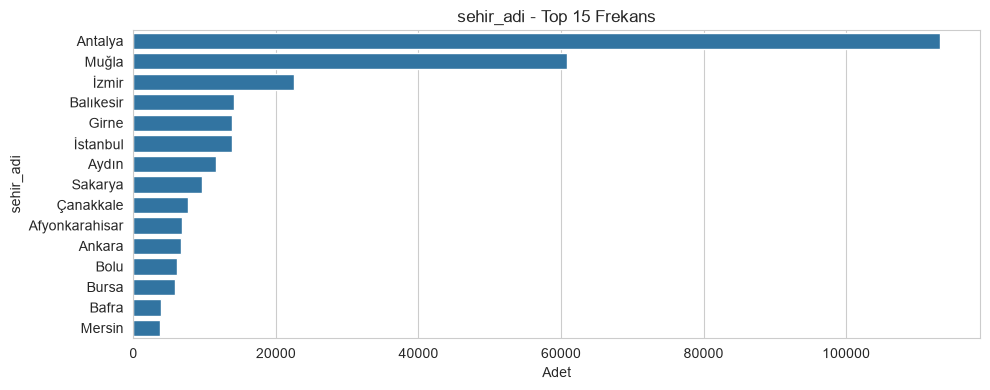

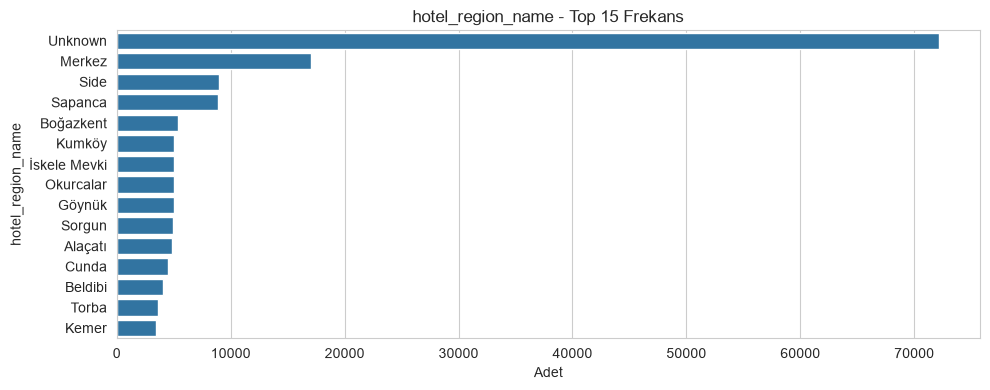

In [8]:
# 8) Tek Degiskenli Kesifsel Analiz (EDA)
if numeric_cols:
    display(df[numeric_cols].describe().T)

    sample_num = numeric_cols[:min(6, len(numeric_cols))]
    df[sample_num].hist(bins=30, figsize=(14, 8))
    plt.suptitle('Secili Sayisal Degisken Dagilimlari')
    plt.tight_layout()
    plt.show()

if cat_cols:
    for col in cat_cols[:min(5, len(cat_cols))]:
        plt.figure(figsize=(10, 4))
        vc = df[col].value_counts().head(15)
        sns.barplot(x=vc.values, y=vc.index)
        plt.title(f'{col} - Top 15 Frekans')
        plt.xlabel('Adet')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

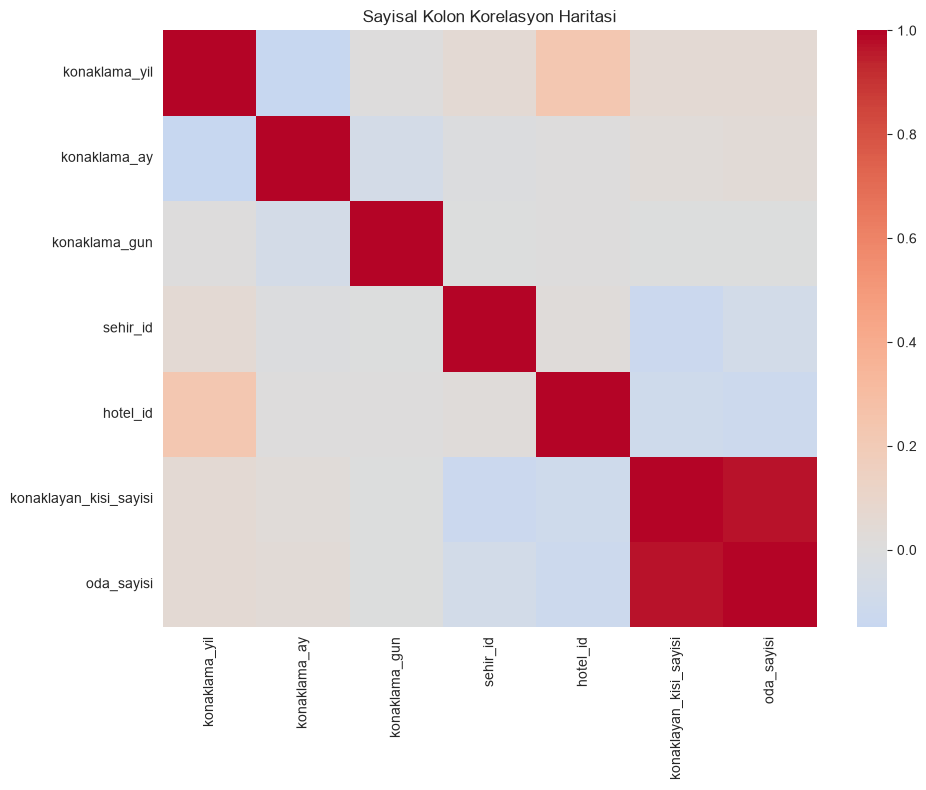

Hedef kolon: Bulunamadi (opsiyonel)


In [9]:
# 9) Iki Degiskenli Iliski Analizi
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Sayisal Kolon Korelasyon Haritasi')
    plt.tight_layout()
    plt.show()

# Hedef kolon otomatik secim (varsa)
candidate_targets = ['target', 'Target', 'label', 'Label', 'AvgSellingPrice']
target_col = next((c for c in candidate_targets if c in df.columns), None)
print('Hedef kolon:', target_col if target_col else 'Bulunamadi (opsiyonel)')

if target_col and cat_cols:
    for col in cat_cols[:min(3, len(cat_cols))]:
        plt.figure(figsize=(10, 4))
        top_vals = df[col].value_counts().head(10).index
        plot_df = df[df[col].isin(top_vals)]
        sns.boxplot(data=plot_df, x=col, y=target_col)
        plt.title(f'{target_col} vs {col}')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()

In [10]:
# 10) Ozellik Muhendisligi ve Kodlama
# Tarih kolonlarindan turetilmis ozellikler
for c in date_cols:
    df[f'{c}_year'] = df[c].dt.year
    df[f'{c}_month'] = df[c].dt.month
    df[f'{c}_dayofweek'] = df[c].dt.dayofweek

# Guncel kolon listeleri
after_num_cols = df.select_dtypes(include=['number']).columns.tolist()
after_cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print('Feature engineering tamamlandi.')
print('Yeni sayisal kolon sayisi:', len(after_num_cols))
print('Yeni kategorik kolon sayisi:', len(after_cat_cols))

Feature engineering tamamlandi.
Yeni sayisal kolon sayisi: 16
Yeni kategorik kolon sayisi: 2


/var/folders/vj/jyn2qp8j5jj6ptl_dmkdj89w0000gp/T/ipykernel_48104/2329141048.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  after_cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [11]:
# 11) Modelleme Oncesi Veri Hazirligi (split, scaling)
# Hedef kolon yoksa placeholder olarak son sayisal kolonu kullanma yerine sadece bilgi ver
if target_col and target_col in df.columns:
    X = df.drop(columns=[target_col])
    y = df[target_col]

    num_features = X.select_dtypes(include=['number']).columns.tolist()
    cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

    preprocess = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline(steps=[('preprocess', preprocess)])
    X_train_prepared = pipeline.fit_transform(X_train)
    X_test_prepared = pipeline.transform(X_test)

    print('Split ve scaling hazirlandi.')
    print('X_train shape:', X_train.shape, 'X_test shape:', X_test.shape)
else:
    print('Hedef kolon bulunamadigi icin split/scaling pipeline demoda birakildi.')

Hedef kolon bulunamadigi icin split/scaling pipeline demoda birakildi.


In [12]:
# 12) Analiz Ciktilarini Kaydetme
output_dir = '../data/analysis_outputs_20260730'
os.makedirs(output_dir, exist_ok=True)

clean_path = os.path.join(output_dir, '20260730_data_cleaned.csv')
summary_path = os.path.join(output_dir, '20260730_summary.json')

# Temiz veri kaydi
df.to_csv(clean_path, index=False)

summary = {
    'rows': int(df.shape[0]),
    'cols': int(df.shape[1]),
    'numeric_cols': int(len(df.select_dtypes(include=['number']).columns)),
    'categorical_cols': int(len(df.select_dtypes(include=['object', 'category']).columns)),
    'datetime_cols': int(len(df.select_dtypes(include=['datetime64[ns]', 'datetime64[ns, UTC]']).columns)),
}
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('Ciktilar kaydedildi:')
print('-', clean_path)
print('-', summary_path)
print('Summary:', summary)

Ciktilar kaydedildi:
- ../data/analysis_outputs_20260730/20260730_data_cleaned.csv
- ../data/analysis_outputs_20260730/20260730_summary.json
Summary: {'rows': 336139, 'cols': 21, 'numeric_cols': 16, 'categorical_cols': 2, 'datetime_cols': 3}


/var/folders/vj/jyn2qp8j5jj6ptl_dmkdj89w0000gp/T/ipykernel_48104/3487701048.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  'categorical_cols': int(len(df.select_dtypes(include=['object', 'category']).columns)),


Antalya toplam rezervasyon satiri: 113,130
Grafikteki yillar (voucher_checkin_date): [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


yil,2020,2021,2022,2023,2024,2025,2026
hafta_no,,,,,,,
1,NaN,10.0,15.0,19.0,15.0,31.0,91.0
2,NaN,9.0,20.0,29.0,27.0,34.0,36.0
3,NaN,14.0,59.0,76.0,46.0,97.0,71.0
4,NaN,44.0,101.0,118.0,118.0,144.0,155.0
5,NaN,58.0,67.0,50.0,73.0,113.0,93.0
6,NaN,40.0,51.0,149.0,39.0,39.0,41.0
7,NaN,30.0,42.0,55.0,28.0,73.0,76.0
8,NaN,44.0,40.0,41.0,44.0,53.0,20.0
9,NaN,22.0,44.0,93.0,52.0,32.0,39.0


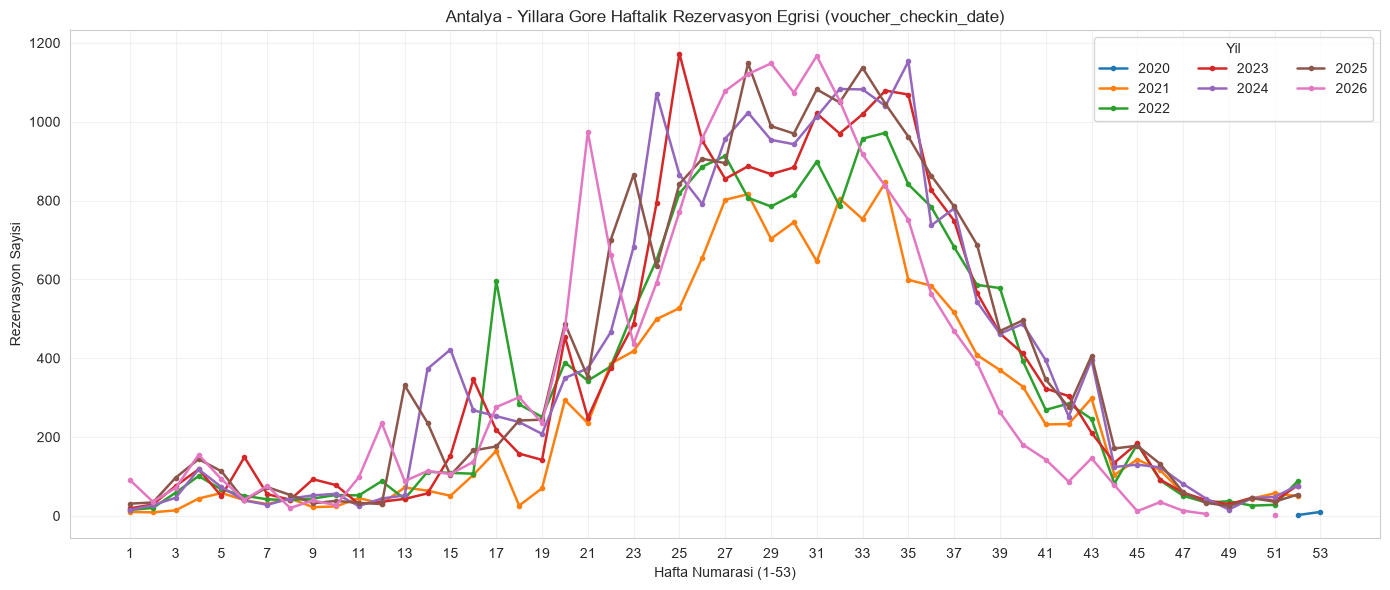

In [14]:
# Antalya bazinda rezervasyonlari her yil icin haftalik cizim (zaman = voucher_checkin_date)
antalya_df = df[df['sehir_adi'].astype(str).str.strip().str.lower() == 'antalya'].copy()

# Zaman ekseni olarak voucher_checkin_date kullan
antalya_df['zaman'] = pd.to_datetime(antalya_df['voucher_checkin_date'], errors='coerce')
antalya_df = antalya_df.dropna(subset=['zaman'])

iso = antalya_df['zaman'].dt.isocalendar()
antalya_df['yil'] = iso.year.astype(int)
antalya_df['hafta_no'] = iso.week.astype(int)

weekly_counts = (
    antalya_df.groupby(['yil', 'hafta_no'])
    .size()
    .reset_index(name='rezervasyon_sayisi')
)

# 1-53 haftayi tum yillar icin tamamla (eksik haftalar 0)
years = sorted(weekly_counts['yil'].unique())
weekly_pivot = (
    weekly_counts.pivot(index='hafta_no', columns='yil', values='rezervasyon_sayisi')
    .reindex(range(1, 54), fill_value=0)
)

print(f"Antalya toplam rezervasyon satiri: {len(antalya_df):,}")
print(f"Grafikteki yillar (voucher_checkin_date): {years}")
display(weekly_pivot.head(12))

plt.figure(figsize=(14, 6))
for y in years:
    plt.plot(weekly_pivot.index, weekly_pivot[y], marker='o', linewidth=1.8, markersize=3, label=str(y))

plt.title('Antalya - Yillara Gore Haftalik Rezervasyon Egrisi (voucher_checkin_date)')
plt.xlabel('Hafta Numarasi (1-53)')
plt.ylabel('Rezervasyon Sayisi')
plt.xticks(range(1, 54, 2), rotation=0)
plt.grid(True, alpha=0.25)
plt.legend(title='Yil', ncol=3)
plt.tight_layout()
plt.show()

2024 check-in kayit sayisi: 61,627
Ortalama lead time (gun): 62.5
Medyan lead time (gun): 26.0


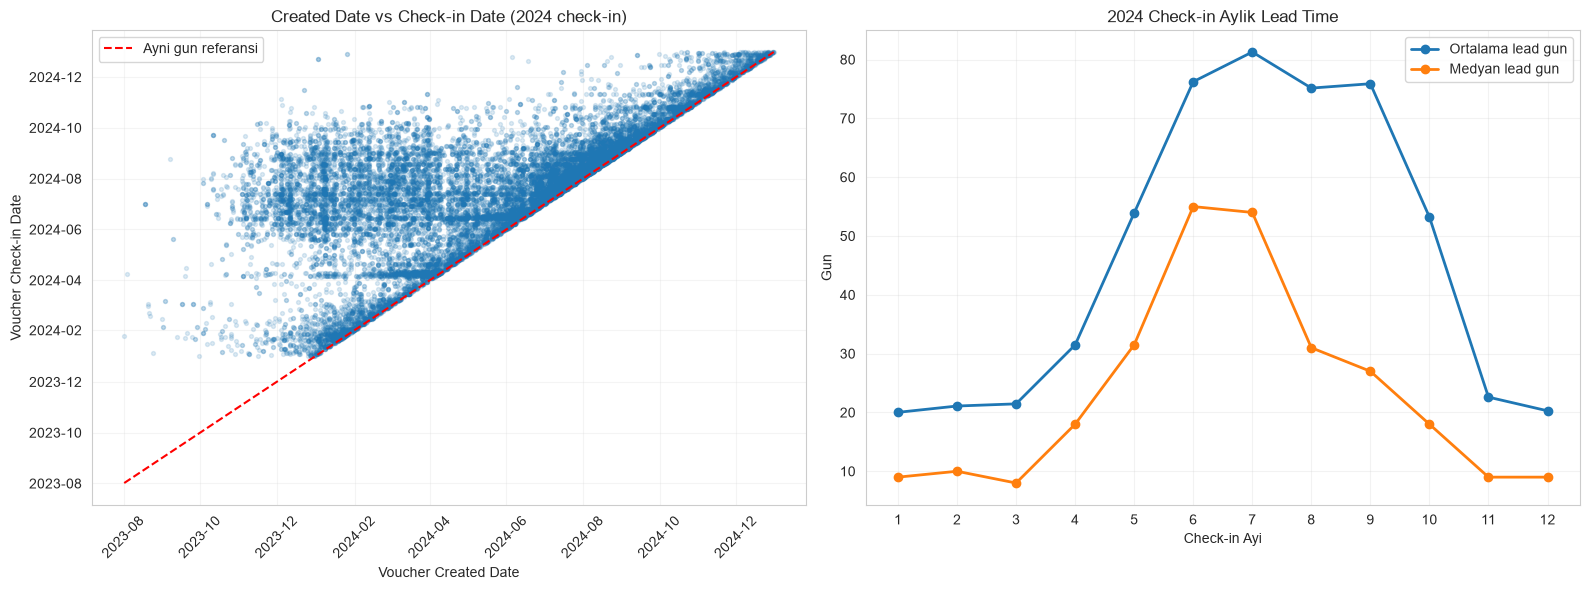

In [15]:
# 2024 icin rezervasyon yapilma tarihi (created) ve gerceklesme tarihi (check-in) iliskisi
import matplotlib.dates as mdates

rel_df = df.copy()
rel_df['created_dt'] = pd.to_datetime(rel_df['voucher_created_date'], errors='coerce')
rel_df['checkin_dt'] = pd.to_datetime(rel_df['voucher_checkin_date'], errors='coerce')

rel_df = rel_df.dropna(subset=['created_dt', 'checkin_dt'])
rel_df = rel_df[rel_df['checkin_dt'].dt.year == 2024].copy()

rel_df['lead_days'] = (rel_df['checkin_dt'] - rel_df['created_dt']).dt.days
rel_df = rel_df[(rel_df['lead_days'] >= 0) & (rel_df['lead_days'] <= 365)]

print(f"2024 check-in kayit sayisi: {len(rel_df):,}")
print(f"Ortalama lead time (gun): {rel_df['lead_days'].mean():.1f}")
print(f"Medyan lead time (gun): {rel_df['lead_days'].median():.1f}")

# Cok yogunluk nedeniyle ornekleme
sample_n = min(20000, len(rel_df))
plot_df = rel_df.sample(sample_n, random_state=42) if len(rel_df) > sample_n else rel_df

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1) Created vs Check-in iliskisi
axes[0].scatter(plot_df['created_dt'], plot_df['checkin_dt'], s=8, alpha=0.15, color='tab:blue')
min_d = min(plot_df['created_dt'].min(), plot_df['checkin_dt'].min())
max_d = max(plot_df['created_dt'].max(), plot_df['checkin_dt'].max())
axes[0].plot([min_d, max_d], [min_d, max_d], color='red', linestyle='--', linewidth=1.5, label='Ayni gun referansi')
axes[0].set_title('Created Date vs Check-in Date (2024 check-in)')
axes[0].set_xlabel('Voucher Created Date')
axes[0].set_ylabel('Voucher Check-in Date')
axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].yaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.2)

# 2) Aylik ortalama ve medyan lead time
lead_by_month = rel_df.groupby(rel_df['checkin_dt'].dt.month)['lead_days'].agg(['mean', 'median'])
axes[1].plot(lead_by_month.index, lead_by_month['mean'], marker='o', linewidth=2, label='Ortalama lead gun')
axes[1].plot(lead_by_month.index, lead_by_month['median'], marker='o', linewidth=2, label='Medyan lead gun')
axes[1].set_title('2024 Check-in Aylik Lead Time')
axes[1].set_xlabel('Check-in Ayi')
axes[1].set_ylabel('Gun')
axes[1].set_xticks(range(1, 13))
axes[1].grid(True, alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

2024 check-in kayit sayisi (temiz): 61,627
Lead time p25/medyan/p75: 6 / 26 / 105 gun


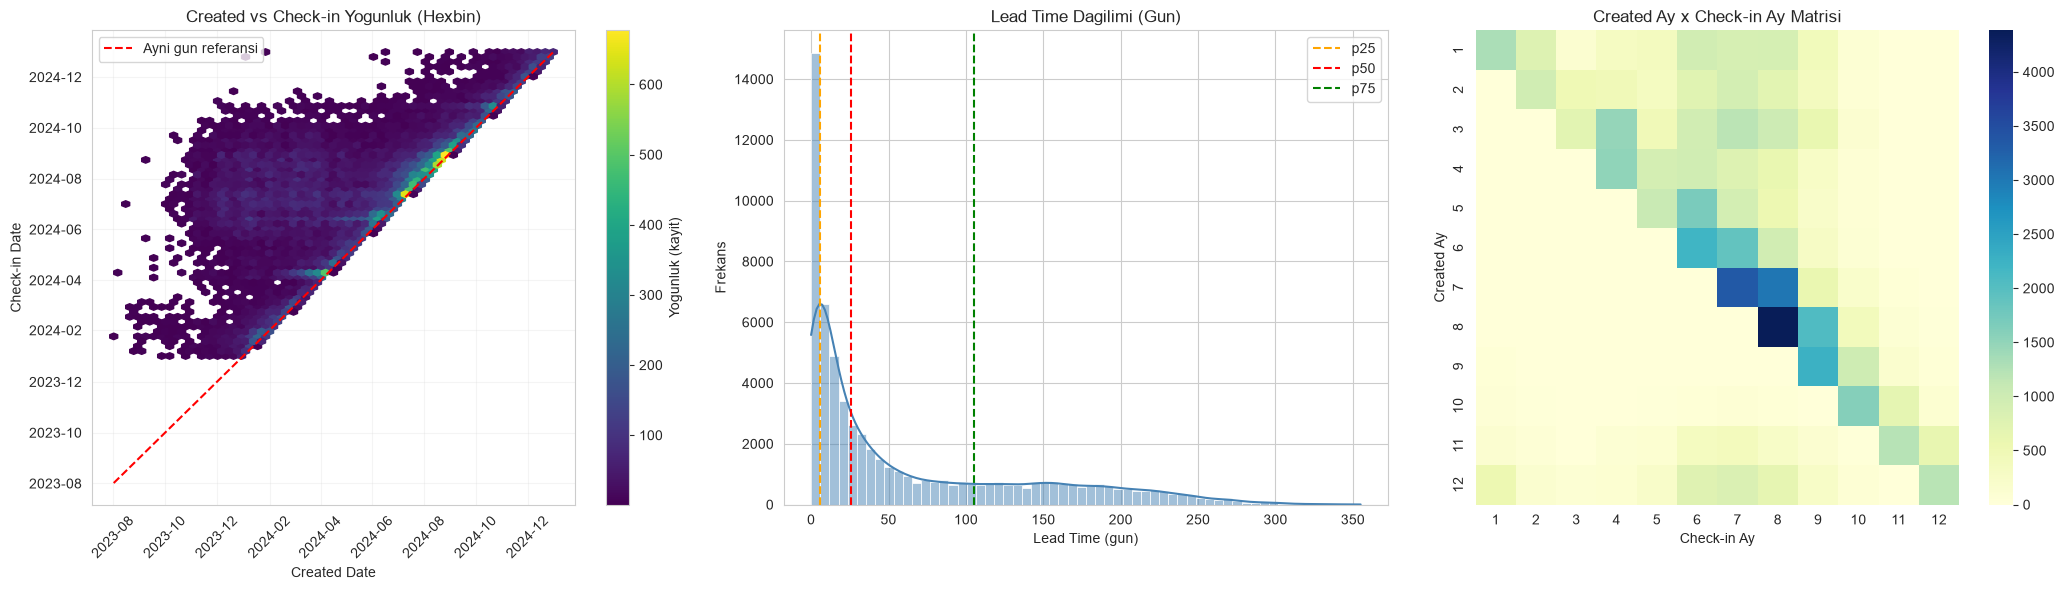

In [17]:
# 2024 created-checkin iliskisi icin daha iyi gorunsellestirme
import matplotlib.dates as mdates

viz_df = df.copy()
viz_df['created_dt'] = pd.to_datetime(viz_df['voucher_created_date'], errors='coerce')
viz_df['checkin_dt'] = pd.to_datetime(viz_df['voucher_checkin_date'], errors='coerce')
viz_df = viz_df.dropna(subset=['created_dt', 'checkin_dt'])
viz_df = viz_df[viz_df['checkin_dt'].dt.year == 2024].copy()

viz_df['lead_days'] = (viz_df['checkin_dt'] - viz_df['created_dt']).dt.days
viz_df = viz_df[(viz_df['lead_days'] >= 0) & (viz_df['lead_days'] <= 365)]

print(f"2024 check-in kayit sayisi (temiz): {len(viz_df):,}")
print(
    f"Lead time p25/medyan/p75: "
    f"{viz_df['lead_days'].quantile(0.25):.0f} / "
    f"{viz_df['lead_days'].median():.0f} / "
    f"{viz_df['lead_days'].quantile(0.75):.0f} gun"
)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1) Scatter yerine hexbin: yogunlugu daha net gosterir
x_num = mdates.date2num(viz_df['created_dt'])
y_num = mdates.date2num(viz_df['checkin_dt'])
hb = axes[0].hexbin(x_num, y_num, gridsize=55, cmap='viridis', mincnt=1)
cb = fig.colorbar(hb, ax=axes[0])
cb.set_label('Yogunluk (kayit)')

min_d = min(viz_df['created_dt'].min(), viz_df['checkin_dt'].min())
max_d = max(viz_df['created_dt'].max(), viz_df['checkin_dt'].max())
axes[0].plot(
    mdates.date2num([min_d, max_d]),
    mdates.date2num([min_d, max_d]),
    'r--',
    linewidth=1.5,
    label='Ayni gun referansi'
)
axes[0].set_title('Created vs Check-in Yogunluk (Hexbin)')
axes[0].set_xlabel('Created Date')
axes[0].set_ylabel('Check-in Date')
axes[0].legend(loc='upper left')
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].yaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.2)

# 2) Lead-time dagilimi + yuzdelikler
sns.histplot(viz_df['lead_days'], bins=60, kde=True, ax=axes[1], color='steelblue')
for q, c in [(0.25, 'orange'), (0.5, 'red'), (0.75, 'green')]:
    axes[1].axvline(viz_df['lead_days'].quantile(q), color=c, linestyle='--', linewidth=1.5, label=f'p{int(q*100)}')
axes[1].set_title('Lead Time Dagilimi (Gun)')
axes[1].set_xlabel('Lead Time (gun)')
axes[1].set_ylabel('Frekans')
axes[1].legend()

# 3) Created ayi x Check-in ayi matrisi
viz_df['created_month'] = viz_df['created_dt'].dt.month
viz_df['checkin_month'] = viz_df['checkin_dt'].dt.month
month_matrix = pd.crosstab(viz_df['created_month'], viz_df['checkin_month'])
month_matrix = month_matrix.reindex(index=range(1, 13), columns=range(1, 13), fill_value=0)

sns.heatmap(month_matrix, cmap='YlGnBu', ax=axes[2])
axes[2].set_title('Created Ay x Check-in Ay Matrisi')
axes[2].set_xlabel('Check-in Ay')
axes[2].set_ylabel('Created Ay')

plt.tight_layout()
plt.show()

In [18]:
# Lead-time istatistik ozeti (created_date -> checkin_date)
stats_df = df.copy()
stats_df['created_dt'] = pd.to_datetime(stats_df['voucher_created_date'], errors='coerce')
stats_df['checkin_dt'] = pd.to_datetime(stats_df['voucher_checkin_date'], errors='coerce')
stats_df = stats_df.dropna(subset=['created_dt', 'checkin_dt'])
stats_df['lead_days'] = (stats_df['checkin_dt'] - stats_df['created_dt']).dt.days
stats_df = stats_df[(stats_df['lead_days'] >= 0) & (stats_df['lead_days'] <= 365)]

stats_2024 = stats_df[stats_df['checkin_dt'].dt.year == 2024]['lead_days']
stats_all = stats_df['lead_days']

def summarize_lead(series, label):
    n = len(series)
    mean = series.mean()
    std = series.std(ddof=1)
    se = std / np.sqrt(n)
    ci_low = mean - 1.96 * se
    ci_high = mean + 1.96 * se
    return {
        'Segment': label,
        'N': n,
        'Mean': mean,
        'Median': series.median(),
        'Std': std,
        'Min': series.min(),
        'P10': series.quantile(0.10),
        'P25': series.quantile(0.25),
        'P75': series.quantile(0.75),
        'P90': series.quantile(0.90),
        'Max': series.max(),
        'Skew': series.skew(),
        'Kurtosis': series.kurtosis(),
        'Mean_CI95_Low': ci_low,
        'Mean_CI95_High': ci_high,
    }

summary_table = pd.DataFrame([
    summarize_lead(stats_2024, '2024 check-in'),
    summarize_lead(stats_all, 'Tum veri')
])

print('Lead-time = checkin_date - created_date (gun)')
display(summary_table.round(2))

print('2024 icin hizli ozet:')
print(f"- Ortalama: {stats_2024.mean():.2f} gun")
print(f"- Medyan: {stats_2024.median():.2f} gun")
print(f"- P25/P75: {stats_2024.quantile(0.25):.2f} / {stats_2024.quantile(0.75):.2f} gun")
print(f"- %95 GA (ortalama): [{summary_table.loc[0, 'Mean_CI95_Low']:.2f}, {summary_table.loc[0, 'Mean_CI95_High']:.2f}]")

Lead-time = checkin_date - created_date (gun)


,Segment,N,Mean,Median,Std,Min,P10,P25,P75,P90,Max,Skew,Kurtosis,Mean_CI95_Low,Mean_CI95_High
0,2024 check-in,61627,62.46,26.0,74.63,0,1.0,6.0,105.0,187.0,355,1.25,0.45,61.87,63.05
1,Tum veri,317832,58.51,25.0,71.57,0,1.0,6.0,90.0,177.0,365,1.42,1.12,58.26,58.76


2024 icin hizli ozet:
- Ortalama: 62.46 gun
- Medyan: 26.00 gun
- P25/P75: 6.00 / 105.00 gun
- %95 GA (ortalama): [61.87, 63.05]


Antalya temiz kayit: 110,642
Antalya bolge sayisi: 55
--- En yuksek hacimli ilk 15 bolge ---


,ReservationCount,AvgLeadDays,MedianLeadDays,AvgPeople,AvgRoom,SharePct
region,,,,,,
Side,8829,75.54,51.0,7.22,2.60,7.98
Unknown,7550,76.59,46.0,7.88,2.81,6.82
Boğazkent,5292,117.92,109.0,10.63,3.85,4.78
Kumköy,5017,109.90,92.0,9.48,3.41,4.53
Okurcalar,5005,107.93,89.0,9.49,3.33,4.52
Göynük,4934,107.46,100.0,10.22,3.73,4.46
İskele Mevki,4906,80.30,48.0,8.85,3.18,4.43
Sorgun,4884,109.66,90.0,10.60,3.78,4.41
Beldibi,3963,87.75,64.0,8.64,3.20,3.58


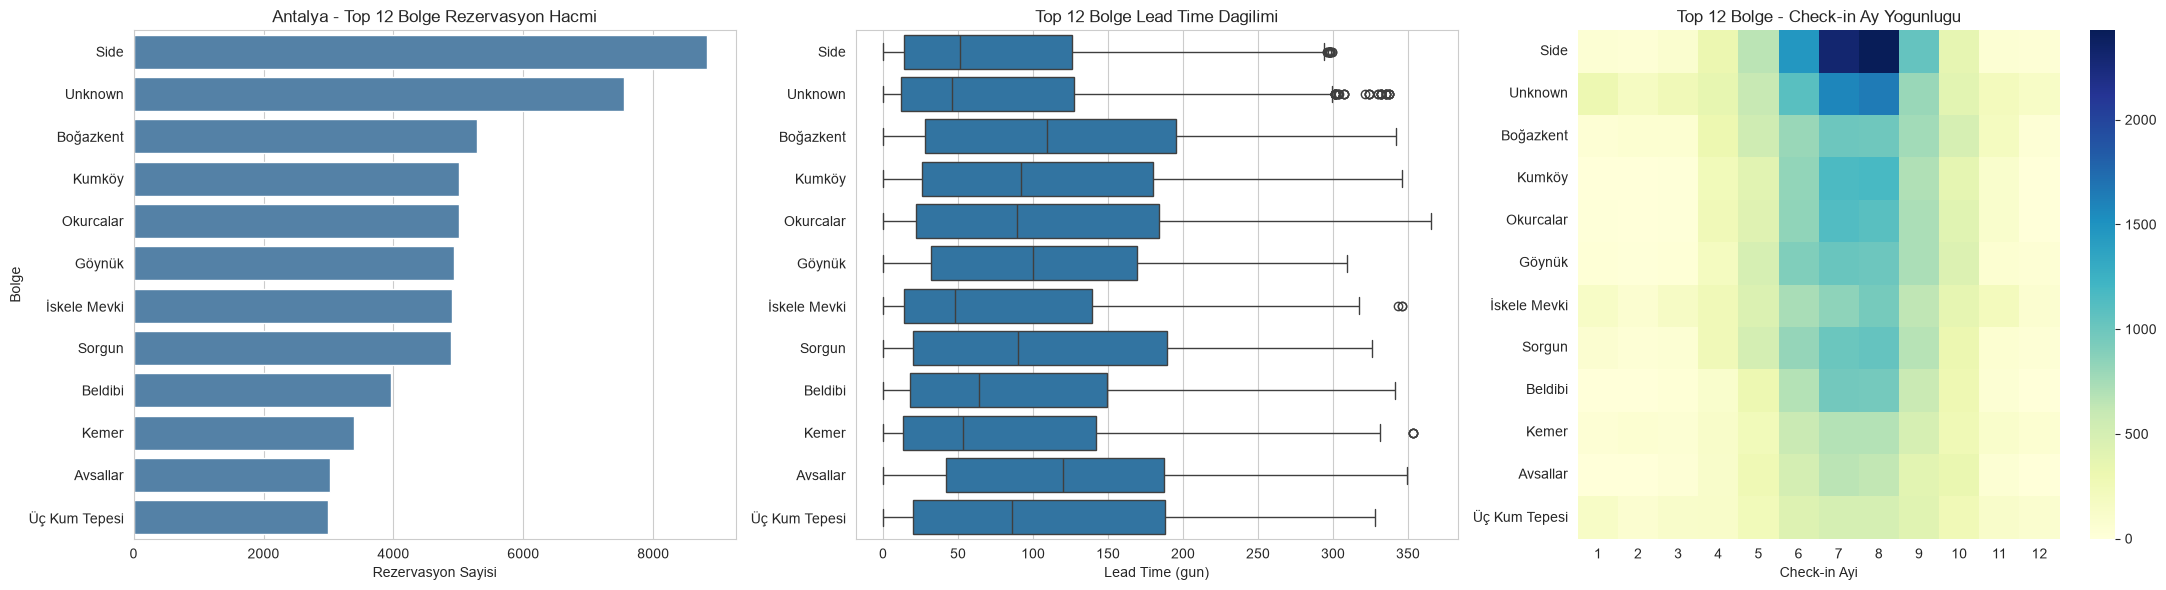

In [19]:
# Antalya'yi bolge bazinda inceleme
antalya_region_df = df[df['sehir_adi'].astype(str).str.strip().str.lower() == 'antalya'].copy()
antalya_region_df['region'] = antalya_region_df['hotel_region_name'].fillna('Unknown').astype(str).str.strip()

# Lead-time hesapla
antalya_region_df['created_dt'] = pd.to_datetime(antalya_region_df['voucher_created_date'], errors='coerce')
antalya_region_df['checkin_dt'] = pd.to_datetime(antalya_region_df['voucher_checkin_date'], errors='coerce')
antalya_region_df['lead_days'] = (antalya_region_df['checkin_dt'] - antalya_region_df['created_dt']).dt.days
antalya_region_df = antalya_region_df[(antalya_region_df['lead_days'] >= 0) & (antalya_region_df['lead_days'] <= 365)]

# Bolge bazli ozet
region_summary = antalya_region_df.groupby('region').agg(
    ReservationCount=('region', 'size'),
    AvgLeadDays=('lead_days', 'mean'),
    MedianLeadDays=('lead_days', 'median'),
    AvgPeople=('konaklayan_kisi_sayisi', 'mean'),
    AvgRoom=('oda_sayisi', 'mean')
).sort_values('ReservationCount', ascending=False)
region_summary['SharePct'] = 100 * region_summary['ReservationCount'] / region_summary['ReservationCount'].sum()

print(f"Antalya temiz kayit: {len(antalya_region_df):,}")
print(f"Antalya bolge sayisi: {region_summary.shape[0]}")
print('--- En yuksek hacimli ilk 15 bolge ---')
display(region_summary.head(15).round(2))

# Gorseller
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

top_regions = region_summary.head(12).index.tolist()

# 1) Bolge bazli rezervasyon hacmi
sns.barplot(
    data=region_summary.head(12).reset_index(),
    y='region',
    x='ReservationCount',
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('Antalya - Top 12 Bolge Rezervasyon Hacmi')
axes[0].set_xlabel('Rezervasyon Sayisi')
axes[0].set_ylabel('Bolge')

# 2) Bolge bazli lead-time dagilimi
box_df = antalya_region_df[antalya_region_df['region'].isin(top_regions)].copy()
sns.boxplot(data=box_df, y='region', x='lead_days', ax=axes[1], order=top_regions)
axes[1].set_title('Top 12 Bolge Lead Time Dagilimi')
axes[1].set_xlabel('Lead Time (gun)')
axes[1].set_ylabel('')

# 3) Check-in ayi x bolge isi haritasi
box_df['checkin_month'] = box_df['checkin_dt'].dt.month
heat = pd.crosstab(box_df['region'], box_df['checkin_month'])
heat = heat.reindex(index=top_regions, columns=range(1, 13), fill_value=0)
sns.heatmap(heat, cmap='YlGnBu', ax=axes[2])
axes[2].set_title('Top 12 Bolge - Check-in Ay Yogunlugu')
axes[2].set_xlabel('Check-in Ayi')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

Kemer toplam kayit: 3,475
Incelenen yillar (son 5): [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Yillik ozet:


,TotalReservation,AvgWeekly,PeakWeekly,PeakWeekNo,PeakWeekCount
yil,,,,,
2022,575,17.42,54,26,54
2023,761,18.56,62,25,62
2024,762,17.32,49,25,49
2025,679,14.45,35,25,35
2026,476,12.53,48,31,48


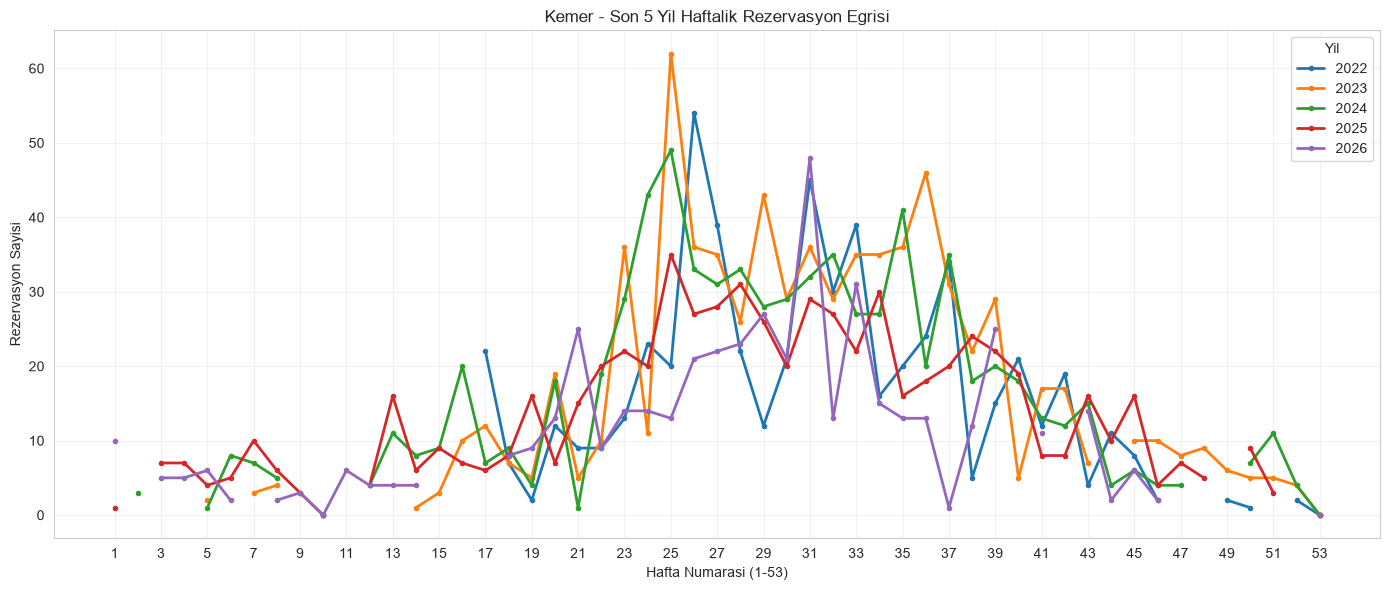

In [20]:
# Kemer ozelinde haftalik bazda son 5 yil analizi (zaman = voucher_checkin_date)
kemer_df = df.copy()
kemer_df['region'] = kemer_df['hotel_region_name'].fillna('Unknown').astype(str).str.strip().str.lower()
kemer_df['city'] = kemer_df['sehir_adi'].astype(str).str.strip().str.lower()

# Antalya icindeki Kemer bolgesi
kemer_df = kemer_df[(kemer_df['city'] == 'antalya') & (kemer_df['region'] == 'kemer')].copy()
kemer_df['checkin_dt'] = pd.to_datetime(kemer_df['voucher_checkin_date'], errors='coerce')
kemer_df = kemer_df.dropna(subset=['checkin_dt'])

iso = kemer_df['checkin_dt'].dt.isocalendar()
kemer_df['yil'] = iso.year.astype(int)
kemer_df['hafta_no'] = iso.week.astype(int)

all_years = sorted(kemer_df['yil'].unique())
selected_years = all_years[-5:] if len(all_years) >= 5 else all_years
kemer_5y = kemer_df[kemer_df['yil'].isin(selected_years)].copy()

weekly_counts = (
    kemer_5y.groupby(['yil', 'hafta_no'])
    .size()
    .reset_index(name='rezervasyon_sayisi')
)

weekly_pivot = (
    weekly_counts.pivot(index='hafta_no', columns='yil', values='rezervasyon_sayisi')
    .reindex(range(1, 54), fill_value=0)
)

# Yillik ozet
year_summary = weekly_counts.groupby('yil').agg(
    TotalReservation=('rezervasyon_sayisi', 'sum'),
    AvgWeekly=('rezervasyon_sayisi', 'mean'),
    PeakWeekly=('rezervasyon_sayisi', 'max')
)
peak_week = weekly_counts.loc[weekly_counts.groupby('yil')['rezervasyon_sayisi'].idxmax(), ['yil', 'hafta_no', 'rezervasyon_sayisi']]
year_summary = year_summary.merge(peak_week.set_index('yil'), left_index=True, right_index=True)
year_summary = year_summary.rename(columns={'hafta_no': 'PeakWeekNo', 'rezervasyon_sayisi': 'PeakWeekCount'})

print(f"Kemer toplam kayit: {len(kemer_df):,}")
print(f"Incelenen yillar (son 5): {selected_years}")
print('\nYillik ozet:')
display(year_summary.round(2))

plt.figure(figsize=(14, 6))
for y in selected_years:
    plt.plot(weekly_pivot.index, weekly_pivot[y], marker='o', linewidth=2, markersize=3, label=str(y))

plt.title('Kemer - Son 5 Yil Haftalik Rezervasyon Egrisi')
plt.xlabel('Hafta Numarasi (1-53)')
plt.ylabel('Rezervasyon Sayisi')
plt.xticks(range(1, 54, 2))
plt.grid(True, alpha=0.25)
plt.legend(title='Yil')
plt.tight_layout()
plt.show()

Kullanilan otel kolonu: hotel_id
Kemer kayit sayisi: 3,475

Yillik unique otel sayilari:


,yil,unique_otel_sayisi
0,2021,7
1,2022,16
2,2023,20
3,2024,18
4,2025,11
5,2026,9


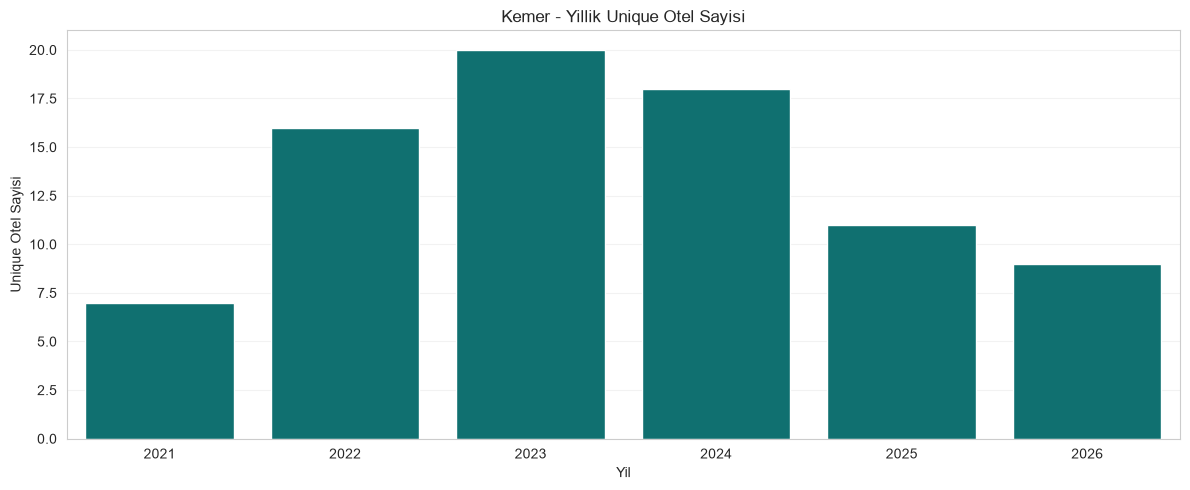

In [21]:
# Kemer'de yillik unique otel sayisi (zaman = voucher_checkin_date)
kemer_hotels = df.copy()
kemer_hotels['region'] = kemer_hotels['hotel_region_name'].fillna('Unknown').astype(str).str.strip().str.lower()
kemer_hotels['city'] = kemer_hotels['sehir_adi'].astype(str).str.strip().str.lower()
kemer_hotels = kemer_hotels[(kemer_hotels['city'] == 'antalya') & (kemer_hotels['region'] == 'kemer')].copy()

kemer_hotels['checkin_dt'] = pd.to_datetime(kemer_hotels['voucher_checkin_date'], errors='coerce')
kemer_hotels = kemer_hotels.dropna(subset=['checkin_dt'])
kemer_hotels['yil'] = kemer_hotels['checkin_dt'].dt.year.astype(int)

# Oteli temsil eden en uygun kolonu sec
candidate_hotel_cols = [
    'hotel_id', 'HotelId', 'hotelid', 'hotel_code', 'hotel_name',
    'otel_id', 'otel_kodu', 'otel_adi'
]
hotel_col = next((c for c in candidate_hotel_cols if c in kemer_hotels.columns), None)

if hotel_col is None:
    raise ValueError('Unique otel sayisi icin uygun bir otel kimlik kolonu bulunamadi.')

annual_unique_hotels = (
    kemer_hotels.groupby('yil')[hotel_col]
    .nunique()
    .reset_index(name='unique_otel_sayisi')
    .sort_values('yil')
)

print(f"Kullanilan otel kolonu: {hotel_col}")
print(f"Kemer kayit sayisi: {len(kemer_hotels):,}")
print('\nYillik unique otel sayilari:')
display(annual_unique_hotels)

plt.figure(figsize=(12, 5))
sns.barplot(data=annual_unique_hotels, x='yil', y='unique_otel_sayisi', color='teal')
plt.title('Kemer - Yillik Unique Otel Sayisi')
plt.xlabel('Yil')
plt.ylabel('Unique Otel Sayisi')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()